<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ma787\AppData\Local\Temp\ipykernel_38840\116671325.py:14: SyntaxWarning: invalid escape sequence '\s'
  X = pd.read_csv('secom.data', sep='\s+', header=None)
C:\Users\ma787\AppData\Local\Temp\ipykernel_38840\116671325.py:15: SyntaxWarning: invalid escape sequence '\s'
  labels = pd.read_csv('secom_labels.data', sep='\s+', header=None, names=['label', 'timestamp'])


Step 1: 데이터를 불러오는 중...
Step 2: 데이터 정제 및 결측치 처리 중 (결측치 50% 이상 제거 로직 포함)...
-> 초기 센서 수: 590개
-> 전처리 후 남은 센서 수: 446개
Step 3: 모델 학습 및 교차 검증 진행 중...
Step 4: 종합 분석 리포트 생성 중...


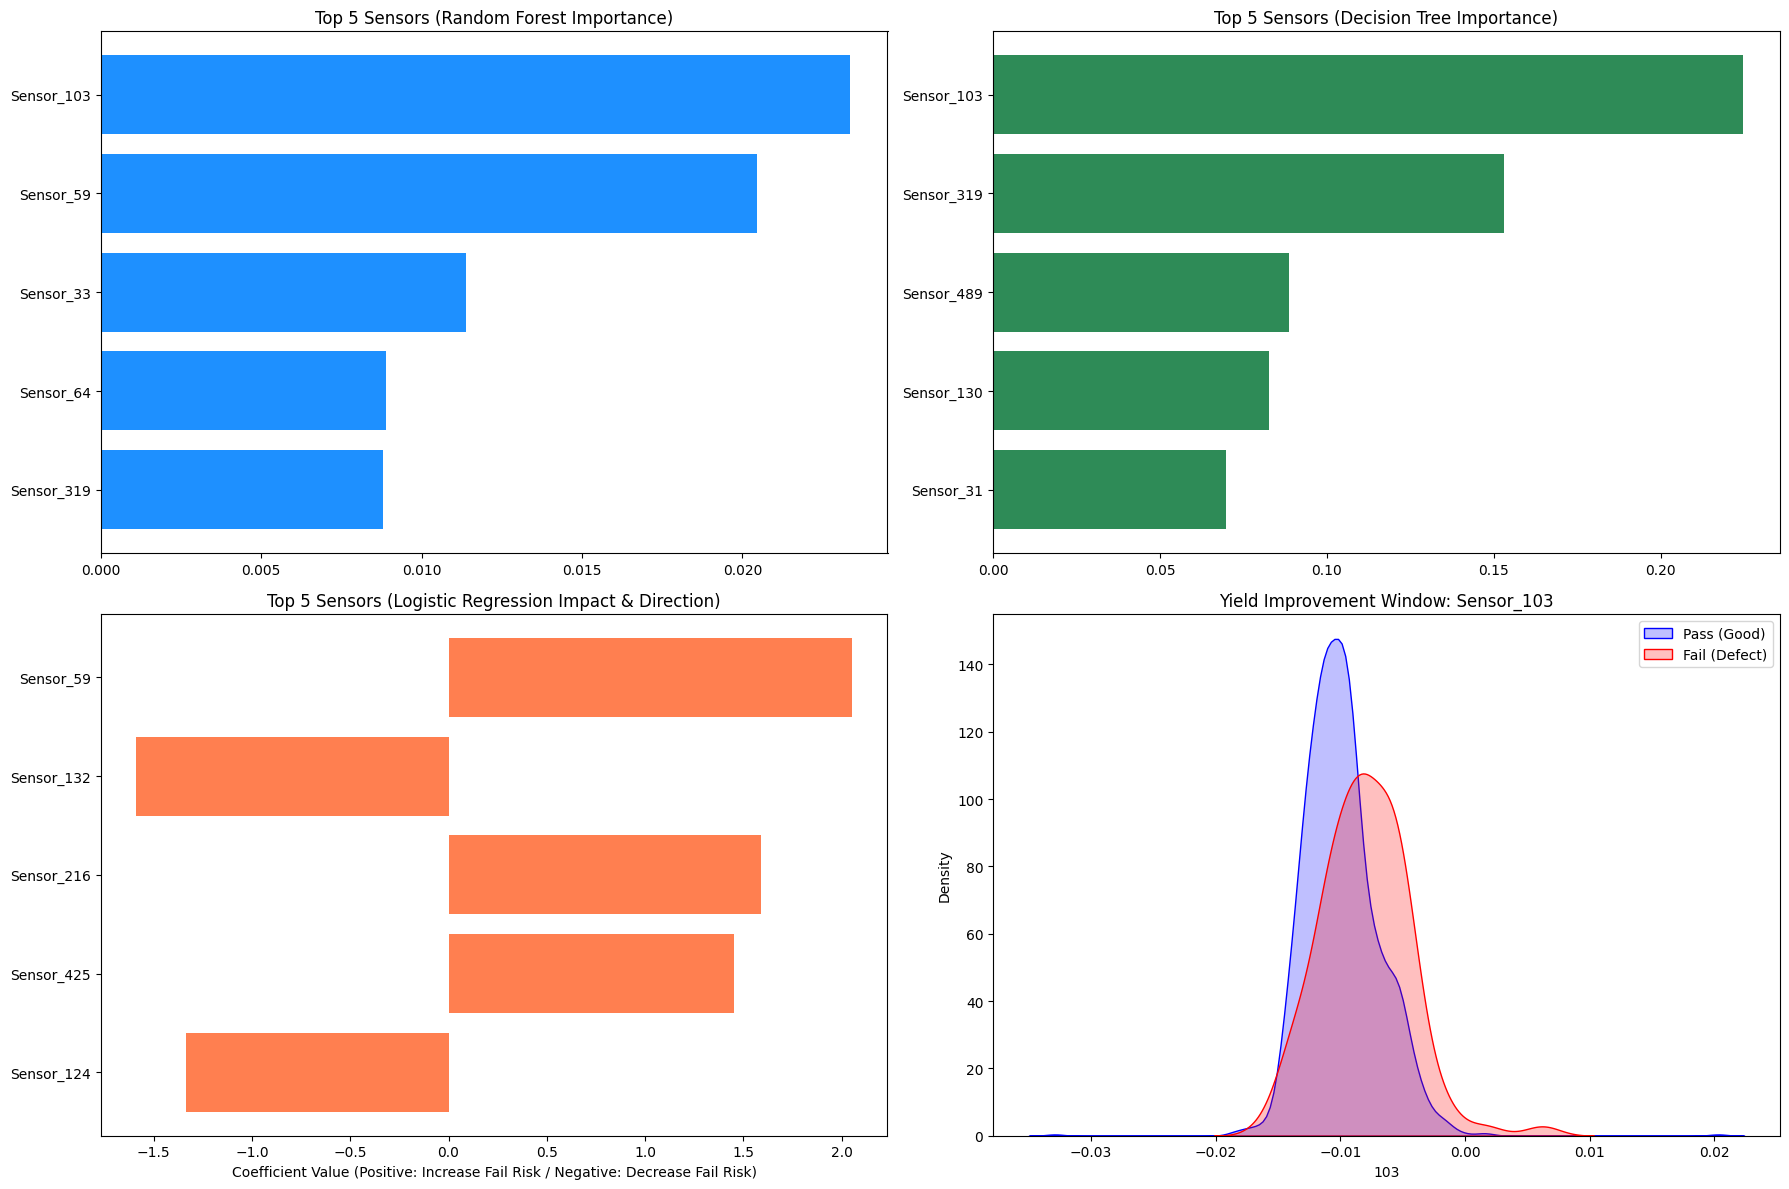


현대모비스 반도체 품질관리 직무 지원용 분석 요약
1. 데이터 정제: 결측치 과다 센서 제거 및 중앙값 대체 후 446개 변수 확정
2. 핵심 관리 인자(RF): Sensor_103 (수율 기여도 최고)
3. 직관적 관리 규칙(DT): Sensor_103 기준 분기점 확인 권고
4. 공정 개선 가이드(LR): Sensor_59 변수의 값이 하향 조정될 때 수율 개선 기대


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# 1. 데이터 로드 및 레이블 전처리
print("Step 1: 데이터를 불러오는 중...")
X = pd.read_csv('secom.data', sep='\s+', header=None)
labels = pd.read_csv('secom_labels.data', sep='\s+', header=None, names=['label', 'timestamp'])
y = labels['label'].replace(-1, 0) # -1(Pass) -> 0, 1(Fail) -> 1

# 2. 데이터 정제 (Cleaning) - 고도화 버전
print("Step 2: 데이터 정제 및 결측치 처리 중 (결측치 50% 이상 제거 로직 포함)...")

# (1) 결측치가 50% 이상인 센서는 분석 신뢰도가 낮으므로 제거
nan_threshold = 0.5
nan_ratio = X.isnull().mean()
cols_to_keep = nan_ratio[nan_ratio < nan_threshold].index
X_filtered = X[cols_to_keep]

# (2) 값이 하나뿐인(분산이 0인) 무의미한 센서 제거
X_clean_cols = X_filtered.loc[:, X_filtered.std() > 0].columns
X_clean = X_filtered[X_clean_cols]

# (3) 남은 결측치를 중앙값(Median)으로 채움 (이상치에 강건한 대응)
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X_clean), columns=X_clean.columns)

print(f"-> 초기 센서 수: {X.shape[1]}개")
print(f"-> 전처리 후 남은 센서 수: {X_imputed.shape[1]}개")

# 3. 모델 학습을 위한 준비 (Scaling & Split)
# 로지스틱 회귀는 변수 간 단위 차이에 민감하므로 스케일링 데이터를 별도 생성합니다.
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, stratify=y, random_state=42)

# 4. 세 가지 모델 동시 학습
print("Step 3: 모델 학습 및 교차 검증 진행 중...")
# (1) Random Forest: 전체적인 중요 변수 식별 및 노이즈 억제
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# (2) Decision Tree: 직관적인 Pass/Fail 분기 규칙 도출
dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)

# (3) Logistic Regression: 변수별 영향의 방향성(증가/감소) 파악
# 학습 데이터에 맞춰 스케일러를 피팅하고 적용합니다.
scaler.fit(X_train)
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(scaler.transform(X_train), y_train)

# 5. 결과 시각화 (종합 리포트)
print("Step 4: 종합 분석 리포트 생성 중...")
plt.figure(figsize=(18, 12))

# [그래프 1] Random Forest 중요 변수 Top 5
plt.subplot(2, 2, 1)
rf_idx = np.argsort(rf.feature_importances_)[-5:]
plt.barh(range(5), rf.feature_importances_[rf_idx], color='dodgerblue')
plt.yticks(range(5), [f"Sensor_{X_imputed.columns[i]}" for i in rf_idx])
plt.title('Top 5 Sensors (Random Forest Importance)')

# [그래프 2] Decision Tree 중요 변수 Top 5
plt.subplot(2, 2, 2)
dt_idx = np.argsort(dt.feature_importances_)[-5:]
plt.barh(range(5), dt.feature_importances_[dt_idx], color='seagreen')
plt.yticks(range(5), [f"Sensor_{X_imputed.columns[i]}" for i in dt_idx])
plt.title('Top 5 Sensors (Decision Tree Importance)')

# [그래프 3] Logistic Regression 영향력 방향 (Top 5)
plt.subplot(2, 2, 3)
lr_coeffs = lr.coef_[0]
lr_idx = np.argsort(np.abs(lr_coeffs))[-5:]
plt.barh(range(5), lr_coeffs[lr_idx], color='coral')
plt.yticks(range(5), [f"Sensor_{X_imputed.columns[i]}" for i in lr_idx])
plt.title('Top 5 Sensors (Logistic Regression Impact & Direction)')
plt.xlabel('Coefficient Value (Positive: Increase Fail Risk / Negative: Decrease Fail Risk)')

# [그래프 4] Golden Window 분석 (RF 1위 변수 기준)
plt.subplot(2, 2, 4)
top_sensor_name = X_imputed.columns[rf_idx[-1]]
sns.kdeplot(X_imputed[y == 0][top_sensor_name], label='Pass (Good)', fill=True, color='blue')
sns.kdeplot(X_imputed[y == 1][top_sensor_name], label='Fail (Defect)', fill=True, color='red')
plt.title(f'Yield Improvement Window: Sensor_{top_sensor_name}')
plt.legend()

plt.tight_layout()
plt.show()

# 6. 기술 통계 요약 출력
print("\n" + "="*60)
print("현대모비스 반도체 품질관리 직무 지원용 분석 요약")
print("="*60)
print(f"1. 데이터 정제: 결측치 과다 센서 제거 및 중앙값 대체 후 {X_imputed.shape[1]}개 변수 확정")
print(f"2. 핵심 관리 인자(RF): Sensor_{X_imputed.columns[rf_idx[-1]]} (수율 기여도 최고)")
print(f"3. 직관적 관리 규칙(DT): Sensor_{X_imputed.columns[dt_idx[-1]]} 기준 분기점 확인 권고")
print(f"4. 공정 개선 가이드(LR): Sensor_{X_imputed.columns[lr_idx[-1]]} 변수의 값이 " + 
      ("하향" if lr_coeffs[lr_idx[-1]] > 0 else "상향") + " 조정될 때 수율 개선 기대")
print("="*60)